In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage
import lmfit as lm
from sklearn.metrics import silhouette_score
from scipy.ndimage import gaussian_filter
from scipy.stats import gamma as gamma_dist
from scipy.special import iv as mod_bessel
from scipy.optimize import fsolve
from scipy.special import gamma as gamma_func
import seaborn as sns
import scipy.optimize as opt
import scipy.stats as stats
from scipy.signal import savgol_filter
from circle_fit import taubinSVD
from circle_fit import lm as lm_fit

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn import metrics
from sklearn.feature_selection import SelectFromModel

from sklearn.model_selection import RandomizedSearchCV
from imblearn.ensemble import BalancedRandomForestClassifier

pd.options.display.float_format = '{:,.4f}'.format

colors = {"Sec9_AA":"c","Sec2_GFP":"brown","WT":"b","Sec9_GFP":"orange","Sec18_AA":"purple","Sec9_WT":"g","WT_37C":"y"}
sets   = ["Sec9_AA","Sec2_GFP","Control","Sec9_GFP","Sec18_AA"]

# Functions 

In [9]:
# For rendering the localizations point-dataset 
# Default parameters:
# --> pixels of 3 x 3 nm are used 
# --> Constant Gaussian filter amplitude = 8/np.sqrt(2) 

In [10]:
def run_grid_randforest(nmin,nmax,do_randsample=1,do_pathway=False):

    #features   = [ 'z1_Tau', 'z2_Tau','Sigma_Tau','varX_Tau','varY_Tau',"R_Tau","Inner_Radius_Tau",
    #             "R_2nd","N_Locs"]

    r = 45
    
    aux_params = geom_params.query("Nexos >= @nmin and Nexos<=@nmax and Inner_Radius < 50 and \
                                        R_PCA < 100 and R_LM<80 and R_Tau<80 and Inner_Radius_Tau<50" ).copy()

    
    aux_params = aux_params.query(" ((GT=='Spot' and Rv >= 15) or \
                                    ((GT=='Ring' and Rv >= 15) ))"
                                   ).copy()
    aux_params["Model"] = aux_params["GT"] + aux_params["Rv"].astype(str)
    
    if do_pathway:
        data = []
        for k in pathway_training.keys():
            data.append(aux_params.query("Model =='%s'"%k ).sample(pathway_training[k],replace=False))
        aux_params = pd.concat(data,ignore_index=True)
        do_randsample = 1     
        
    if do_randsample != 1:        
        size = do_randsample # size
        replace = False  # with replacement
        fn = lambda obj: obj.loc[np.random.choice(obj.index, size, replace),:]
        aux_params = aux_params.groupby('Model',as_index=False).apply(fn)        
        aux_params.reset_index(inplace=True)

    if len(aux_params)<500:
        return (0,0,0,0,0)
    
    aux_params = aux_params.sort_values("File_ID")    
    
    idModel,x = np.unique(aux_params["Model"],return_counts=True)
    idModel   = idModel[x>180]      
    aux_params = aux_params.loc[np.isin(aux_params["Model"],idModel)]

    scores      = pd.DataFrame(data=[],index=[0])
    feat_import = pd.DataFrame(data=[],index=features)
    nsites      = pd.DataFrame(data=[],index=[0])

    for j in idModel:
        x  = aux_params.loc[aux_params["Model"]==j].copy()    
        nsites.loc[0,j] = "%d"%len(x)

    labels  = aux_params["Model"].values

    data = aux_params[features].values
    #data = np.insert(data,0,aux_params.index,axis=1)
    #data = StandardScaler().fit_transform(data[:,1:])
    
    train,test,labels_train,labels_test = train_test_split(data,
                                                           labels, test_size=0.33)#, random_state=40,
    
    #print(len(train),len(test))
    
    # Number of trees in random forest
    n_estimators = np.arange(100,1100,200)
    # Number of features to consider at every split
    max_features = ['log2', 'sqrt']
    # Maximum number of levels in tree
    max_depth = np.arange(5,40,5).tolist()
    max_depth.append(None)
    # Minimum number of samples required to split a node
    min_samples_split = [2, 5, 10]
    # Minimum number of samples required at each leaf node
    min_samples_leaf = [1, 2, 4]
    # Method of selecting samples for training each tree
    bootstrap = [True, False]
    # Create the random grid
    random_grid = {'n_estimators': n_estimators,
                   'max_features': max_features,
                   'max_depth': max_depth,
                   'min_samples_split': min_samples_split,
                   'min_samples_leaf': min_samples_leaf,                   
                   }
    print(random_grid)
    
    # Random search of parameters, using 3 fold cross validation, 
    # search across 100 different combinations, and use all available cores
    clf =  RandomForestClassifier()
    clf_random = RandomizedSearchCV(estimator = clf, param_distributions = random_grid, 
                                    n_iter = 100, cv = 3, verbose=1, random_state=42, n_jobs = -1)
    # Fit the random search model
    clf_random.fit(train, labels_train)
   
    return(len(train),len(test),clf_random,idModel)

In [138]:
# For run the RF trainining to classify between Compact and Expanded ExHOS
# Compact  -->  15 nm < True ExHOS radius < 22.5 nm
# Expanded -->  28 nm < True ExHOS radius < 50.0 nm

def run_randforest_dist_prox(clf,nmin,nmax,do_randsample=1,do_pathway=False):
    
    aux_params = geom_params_rings.query("Nexos >= @nmin and Nexos<=@nmax and Inner_Radius < 50 and Max_Exos == Nexos \
                                        and R_LM<80 and R_Tau<80 and Inner_Radius_Tau<50" ).copy()

    
    aux_params = aux_params.query("GT=='N_Fold' "                                  
                                   ).copy()
    
    aux_params.loc[(aux_params["Rv"]>=15) & (aux_params["Rv"]<22.5),"Model" ] = "Compact"
    aux_params.loc[(aux_params["Rv"]>28) & (aux_params["Rv"]<50),"Model" ]    = "Expanded" 
          
    if do_randsample != 1:        
        size = do_randsample # size
        replace = False  # with replacement
        fn = lambda obj: obj.loc[np.random.choice(obj.index, size, replace),:]
        aux_params = aux_params.groupby('Model',as_index=False).apply(fn)        
        aux_params.reset_index(inplace=True)

    if len(aux_params)<500:
        return (0,0,0,0,0)
    
    aux_params = aux_params.sort_values("File_ID")    
    
    idModel,x = np.unique(aux_params["Model"],return_counts=True)

    scores      = pd.DataFrame(data=[],index=[0])
    feat_import = pd.DataFrame(data=[],index=features)
    nsites      = pd.DataFrame(data=[],index=[0])

    for j in idModel:
        x  = aux_params.loc[aux_params["Model"]==j].copy()    
        nsites.loc[0,j] = "%d"%len(x)

    labels  = aux_params["Model"].values

    data = aux_params[features].values
  
    
    train,test,labels_train,labels_test = train_test_split(data,
                                                           labels, test_size=0.33)#, random_state=40,
    #print(len(train),len(test))
    
    clf.fit(train, labels_train)
    labels_pred = clf.predict(test)
    
    x = metrics.confusion_matrix(labels_test, labels_pred)#,normalize='true')

    if do_plot:
        plt.imshow(x/np.sum(x,axis=1),cmap='RdBu',vmin=0,vmax=1)
        #plt.colorbar(label="Predicted Fraction",location='right')            
        plt.xticks(np.arange(len(x)),idModel,rotation=90,fontsize=12)

        plt.yticks(np.arange(len(x)),idModel,rotation=0 ,fontsize=12)
        #plt.title("Ring_R%d"%r,fontsize=14)
        """for i in range(len(x)):    
            for j in range(len(x)):                    
                plt.text(i+0.,j+0.,"%.2f"%x[j,i],ha='center')
        """

        plt.ylabel("Truth label")
        plt.xlabel("Predicted label")
        #plt.tight_layout()
        #plt.savefig("figs/for_presentation/Confusion_Matrix_RandomForest.png",dpi=200)
        #plt.show()
        #print(x)
    score = clf.score(test, labels_test)
    return(len(train),len(test),clf,score,x,idModel)

# Run

In [134]:
###----Importing data----
##----Synthetic sites----
# Contains the geometrical features
geom_params_rings = pd.read_csv("Geom_params_data_Simulate_Ring_Nfold_FinalDataset.csv")
# Contains the localization coordinates of each site
alldata_rings   =  read_params("Alldata_Simulate_Ring_Nfold_FinalDataset.csv")

##----Experimental sites----
sets          = ["Sec9_AA","Sec2_GFP","Control","Control_1","Sec9_GFP","Sec18_AA","WT_37C","Sec9_WT","WT"]
exp_params    = pd.read_csv("Geom_params_data_Experimental_FinalDataset.csv")    

for idc in ["X_Locs","Y_Locs","X_Exos","Y_Exos","LocP"]:
    for id in alldata_rings.index:    
        x=alldata_rings.loc[id,idc]
        x=x.replace("["," ").replace("]","").split()
        alldata_rings.at[id,idc] = np.array(x).astype(np.float32)

In [139]:
""" 
#Best  parameters for just rings with 6<=nexos<=8
{'n_estimators': 100,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': 5} """

features   = [ 'z1_Tau', 'z2_Tau','Sigma_Tau',"R_Tau","Inner_Radius_Tau",
             "R_2nd"]

# RF classs with optimized parameters
clf_opt = RandomForestClassifier(max_depth=5,
                                  n_estimators=100,min_samples_split=5,
                             min_samples_leaf=2,max_features='sqrt',bootstrap= True)

# Importing file with 

##--------------------------------------------------------------------------------------------------##
do_plot = False
n_trials= 30

feat_import = pd.DataFrame(data=np.zeros(len(features)),index=features)
score       = 0.
conf_mat    = np.array([[0.,0.],[0.,0.]])

# The RF training/test/prediction cycle is performed several times by randomizing the training dataset
for it in range(n_trials):    
    len_train,len_test,clf,score_aux,conf_mat_aux,idModel = run_randforest_dist_prox(clf_opt,6,8,do_randsample=900,do_pathway=False)
    score    += score_aux
    conf_mat += conf_mat_aux
    if it%10 == 0:
        print(len_train,len_test,it)
    ##--------------------------------------------------------------------------------------------------##
    data = exp_params[features].values
    #data = StandardScaler().fit_transform(data)

    labels_pred = clf.predict(data)      
    feat_import[0] += clf.feature_importances_    
    ##--------------------------------------------------------------------------------------------------##  
    exp_params["Pred"] = labels_pred
    if it == 0:
        exp_params[idModel] = clf.predict_proba(data)
    else:
        exp_params[idModel] += clf.predict_proba(data)
    ##--------------------------------------------------------------------------------------------------##       


    #To generate average population
    #data = exp_params.query("Set in ['WT'] and File_ID>2").copy()    
    
    data = exp_params.copy()    
    preds = data.Pred.unique()
    preds = np.sort(preds)

    data = data.groupby(["Set","File_ID","Pred"])[["Pred"]].count()/data.groupby(["Set","File_ID"])[["Pred"]].count() 
    if it == 0:
        results = data.copy()
        results.rename(columns={"Pred":"Iter0"},inplace=True)                
    else:
        results["Iter%d"%it] = data["Pred"]
        
exp_params[idModel] /= n_trials
feat_import /= n_trials
conf_mat    /= n_trials
score       /= n_trials
feat_import.rename(columns={0:"Feature_Importance"},inplace=True)

1206 594 0
1206 594 10
1206 594 20


The average accuracy achieved is :  0.93


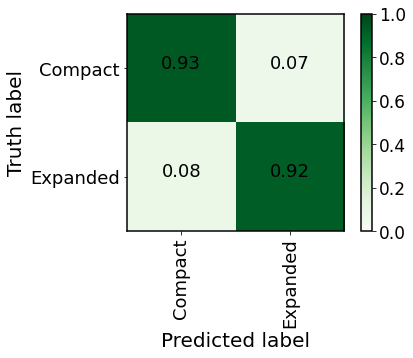

In [143]:
# Plotting the confusion matrix
x = conf_mat.copy()
plt.imshow(x/np.sum(x,axis=1),cmap='Greens',vmin=0,vmax=1)
plt.xticks(np.arange(len(x)),idModel,rotation=90,fontsize=18)
plt.yticks(np.arange(len(x)),idModel,rotation=0 ,fontsize=18)

plt.colorbar()
plt.ylabel("Truth label",fontsize=20)
plt.xlabel("Predicted label",fontsize=20)
#plt.tight_layout()

for i in range(len(x)):    
    for j in range(len(x)):                    
        plt.text(i+0.,j+0.,"%.2f"%(x[j,i]/np.sum(x[j])),ha='center')

print("The average accuracy achieved is :  %.2f"%score)
#plt.show()
#print(x)

Text(0, 0.5, '')

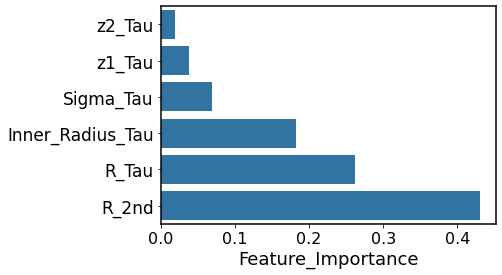

In [144]:
# Plotting the importance score for the features
feat_import.sort_values("Feature_Importance",inplace=True)
sns.barplot(data=feat_import,x='Feature_Importance',y=feat_import.index)
plt.ylabel("")
#plt.savefig("figs/Features_Importance.svg")

In [145]:
# Assigning to each site the high average predicted class
pred                =  np.argmax(exp_params[idModel].values,axis=1)
exp_params["Pred"]  = idModel[pred]

In [152]:
# Here, for each dataset and replicate, the standard deviation for each class score is computed over the training/prediction cycles
data = []
for ids in sets:    
    for i,idf in enumerate(exp_params.query("Set == '%s'"%ids)["File_ID"].unique()):
        n =  len(exp_params.query("Set == '%s' and File_ID==@idf"%ids))
        p      = { idm: results.loc[ids,idf,idm].mean() for idm in preds}
        p_std  = {"STD_"+idm: results.loc[ids,idf,idm].std() for idm in preds}
        data.append([ids,i+1,*p.values(),*p_std.values(),n])
data = pd.DataFrame(data,columns=["Set","Replicate",*p.keys(),*p_std.keys(),"Count"])
data[data.columns[1:]] = data[data.columns[1:]].astype(float)
results_over_preds = data.groupby(["Set","Replicate"]).mean() 
results_over_preds["N_RF_Rounds"] = n_trials
#results_over_preds.to_csv("Results_over_RFpreds_using_%s_Nov17.csv"%method)
results_over_preds

Compact  Expanded  STD_Compact  STD_Expanded    Count  \
Set      Replicate                                                          
Sec18_AA 1.0000      0.0194    0.9806       0.0066        0.0066  62.0000   
         2.0000      0.0964    0.9036       0.0276        0.0276  56.0000   
         3.0000      0.0592    0.9408       0.0192        0.0192 102.0000   
Sec2_GFP 1.0000      0.2128    0.7872       0.0176        0.0176  65.0000   
         2.0000      0.3020    0.6980       0.0132        0.0132  51.0000   
         3.0000      0.2272    0.7728       0.0350        0.0350  49.0000   
Sec9_GFP 1.0000      0.1167    0.8833       0.0170        0.0170  66.0000   
         2.0000      0.0639    0.9361       0.0124        0.0124  72.0000   
         3.0000      0.0717    0.9283       0.0132        0.0132  60.0000   
WT       1.0000      0.2638    0.7362       0.0352        0.0352  47.0000   
         2.0000      0.3700    0.6300       0.0638        0.0638  20.0000   
         3.0000      0.3229    0.6771       0.0252        0.0252  67.0000   

                    N_RF_Rounds  
Set      Replicate               
Sec18_AA 1.0000              30  
         2.0000              30  
         3.0000              30  
Sec2_GFP 1.0000              30  
         2.0000              30  
         3.0000              30  
Sec9_GFP 1.0000              30  
         2.0000              30  
         3.0000              30  
WT       1.0000              30  
         2.0000              30  
         3.0000              30

In [157]:
# The average and pooled STD is computed over the replicates for each dataset
results_b = data.groupby(["Set"])[preds].agg("mean")
for i in results_b.index: 
    aux  = results_over_preds.loc[i][["Compact","STD_Compact","Count"]].copy()
    nreps= len(aux)
    std  = np.sqrt(np.sum(aux["STD_Compact"]**2 * (aux["Count"]-1))/np.sum(aux["Count"]-len(aux))) 
    w_i  = aux["Count"].values   
    sem  = np.sum(w_i*(aux["Compact"]-results_b.loc[i,"Compact"])**2 + aux["Compact"]**2)
    sem  = sem* np.sum(w_i)/(np.sum(w_i)**2-np.sum(w_i**2))
    sem  = np.sqrt(sem)
    results_b.loc[i,"STD"] = std   
    results_b.loc[i,"SEM"] = sem   

results_b["Count"] = data.groupby(["Set"])[["Count"]].sum().astype(int)
results_b["N_replicates"] = data.groupby(["Set"])[["Replicate"]].agg("max").astype(int)
results_b
#results_b.to_csv("Results_over_replicates_using_%s_Nov17.csv"%method)

,Compact,Expanded,STD,SEM,Count,N_replicates
Set,,,,,,
Sec18_AA,0.0583,0.9417,0.0197,0.0366,220,3
Sec2_GFP,0.2473,0.7527,0.0237,0.0633,165,3
Sec9_GFP,0.0841,0.9159,0.0145,0.0316,198,3
WT,0.3189,0.6811,0.0375,0.0791,134,3
